# Experiment 001: Heart Segmentation Baseline — TotalSegmentator

## Setup

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import SimpleITK as sitk
import yaml

In [2]:
SEED = 42
np.random.seed(SEED)

EXPERIMENT_DIR = Path(__file__).parent if "__file__" in dir() else Path.cwd()
REPO_ROOT = EXPERIMENT_DIR.parent.parent
CONFIG_PATH = EXPERIMENT_DIR / "config.yaml"
METRICS_PATH = EXPERIMENT_DIR / "metrics.json"
FIGURES_DIR = EXPERIMENT_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print(f"Experiment: {config['experiment']['id']} — {config['experiment']['name']}")

Experiment: exp-001 — heart-seg-baseline


In [3]:
RESAMPLED_DIR = REPO_ROOT / config["data"]["resampled_dir"]
HEART_MASKS_DIR = REPO_ROOT / config["data"]["heart_masks_dir"]
SCAN_INDEX_PATH = REPO_ROOT / config["data"]["scan_index"]
HEART_MASKS_DIR.mkdir(parents=True, exist_ok=True)

scan_df = pd.read_csv(SCAN_INDEX_PATH)
print(f"COCA scan index: {len(scan_df)} patients")
print(scan_df.head(3))

COCA scan index: 787 patients
   patient_id       scan_id  voxels  num_slices  \
0         135  02645573f01f       0           0   
1         307  9abafce409b3      12           1   
2         763  9c69dfe283d3       0           0   

                                         folder_path  
0  /Users/shreyaschitransh/code/eat-segmentation/...  
1  /Users/shreyaschitransh/code/eat-segmentation/...  
2  /Users/shreyaschitransh/code/eat-segmentation/...  


In [ ]:

import torch
from totalsegmentator.python_api import totalsegmentator

device = config["totalsegmentator"]["device"]
if device == "mps" and not torch.backends.mps.is_available():
    device = "cpu"
    print("WARNING: MPS not available, falling back to CPU")
print(f"Device: {device}")
print(f"TotalSegmentator fast={config['totalsegmentator']['fast']}, "
      f"roi_subset={config['totalsegmentator']['roi_subset']}")

Device: mps
TotalSegmentator fast=True, roi_subset=['heart']


## Data — Select Test Patients

In [ ]:

available = sorted([p.name for p in RESAMPLED_DIR.iterdir() if p.is_dir()])
test_patients = available[:config["data"]["test_n_patients"]]
print(f"Test patients: {test_patients}")

for pid in test_patients:
    img_path = RESAMPLED_DIR / pid / f"{pid}_img.nii.gz"
    assert img_path.exists(), f"Missing: {img_path}"
    print(f"  {pid}: {img_path.stat().st_size / 1e6:.1f} MB")

Test patients: ['0024645fda6a', '008ddde695d8', '00a011f0efec']
  0024645fda6a: 5.7 MB
  008ddde695d8: 7.0 MB
  00a011f0efec: 5.8 MB


## Run — TotalSegmentator on 3 Pilot Patients

In [ ]:
def run_totalseg_heart(scan_id: str, resampled_dir: Path, output_base: Path,
                        task: str, fast: bool, roi_subset: list[str], device: str):
    """Run TotalSegmentator and return the heart mask + inference time."""
    img_path = resampled_dir / scan_id / f"{scan_id}_img.nii.gz"
    out_dir = output_base / scan_id
    out_dir.mkdir(parents=True, exist_ok=True)
    heart_out = out_dir / "heart.nii.gz"

    if heart_out.exists():
        print(f"  {scan_id}: cached")
        t = 0.0
    else:
        t0 = time.time()
        totalsegmentator(
            input=str(img_path),
            output=str(out_dir),
            task=task,
            fast=fast,
            roi_subset=roi_subset,
            device=device,
            quiet=True,
        )
        t = time.time() - t0
        print(f"  {scan_id}: {t:.1f}s")

    heart_img = nib.load(heart_out)
    return heart_img, t

print("Running TotalSegmentator on pilot patients (first run downloads models ~400MB)...")
pilot_results = {}
total_time = 0
for pid in test_patients:
    heart_img, elapsed = run_totalseg_heart(
        pid, RESAMPLED_DIR, HEART_MASKS_DIR,
        task=config["totalsegmentator"]["task"],
        fast=config["totalsegmentator"]["fast"],
        roi_subset=config["totalsegmentator"]["roi_subset"],
        device=device,
    )
    pilot_results[pid] = {"heart_img": heart_img, "time_s": elapsed}
    total_time += elapsed

avg_time = total_time / len(test_patients) if test_patients else 0
print(f"\nAverage inference time: {avg_time:.1f}s per patient")
print(f"Estimated time for all 787 patients: {avg_time * 787 / 3600:.1f} hours")

Running TotalSegmentator on pilot patients (first run downloads models ~400MB)...
  0024645fda6a: cached
  008ddde695d8: cached
  00a011f0efec: cached

Average inference time: 0.0s per patient
Estimated time for all 787 patients: 0.0 hours


## Evaluation — Sanity Checks on Heart Masks

In [ ]:
def heart_mask_stats(heart_img: nib.Nifti1Image, scan_id: str) -> dict:
    """Compute basic stats on the heart mask."""
    arr = heart_img.get_fdata()
    vox_vol_ml = np.prod(heart_img.header.get_zooms()) / 1000.0
    heart_voxels = (arr > 0).sum()
    heart_vol_ml = heart_voxels * vox_vol_ml

    coords = np.argwhere(arr > 0)
    if len(coords) > 0:
        bbox_min = coords.min(axis=0)
        bbox_max = coords.max(axis=0)
        bbox_size_vox = bbox_max - bbox_min + 1
    else:
        bbox_min = bbox_max = bbox_size_vox = np.zeros(3)

    return {
        "scan_id": scan_id,
        "heart_vol_ml": float(heart_vol_ml),
        "heart_voxels": int(heart_voxels),
        "bbox_z_slices": int(bbox_size_vox[0]),
        "bbox_y_px": int(bbox_size_vox[1]),
        "bbox_x_px": int(bbox_size_vox[2]),
    }

stats_rows = []
for pid, res in pilot_results.items():
    s = heart_mask_stats(res["heart_img"], pid)
    stats_rows.append(s)
    print(f"  {pid}: {s['heart_vol_ml']:.0f} mL, bbox z={s['bbox_z_slices']} y={s['bbox_y_px']} x={s['bbox_x_px']}")

stats_df = pd.DataFrame(stats_rows)
print(f"\nPublished cardiac volume reference: ~400-900 mL total heart")
print(f"Our measurements: {stats_df['heart_vol_ml'].mean():.0f} mL (mean)")

  0024645fda6a: 923 mL, bbox z=230 y=199 x=41
  008ddde695d8: 1162 mL, bbox z=233 y=196 x=44
  00a011f0efec: 916 mL, bbox z=209 y=226 x=41

Published cardiac volume reference: ~400-900 mL total heart
Our measurements: 1000 mL (mean)


## Visualization

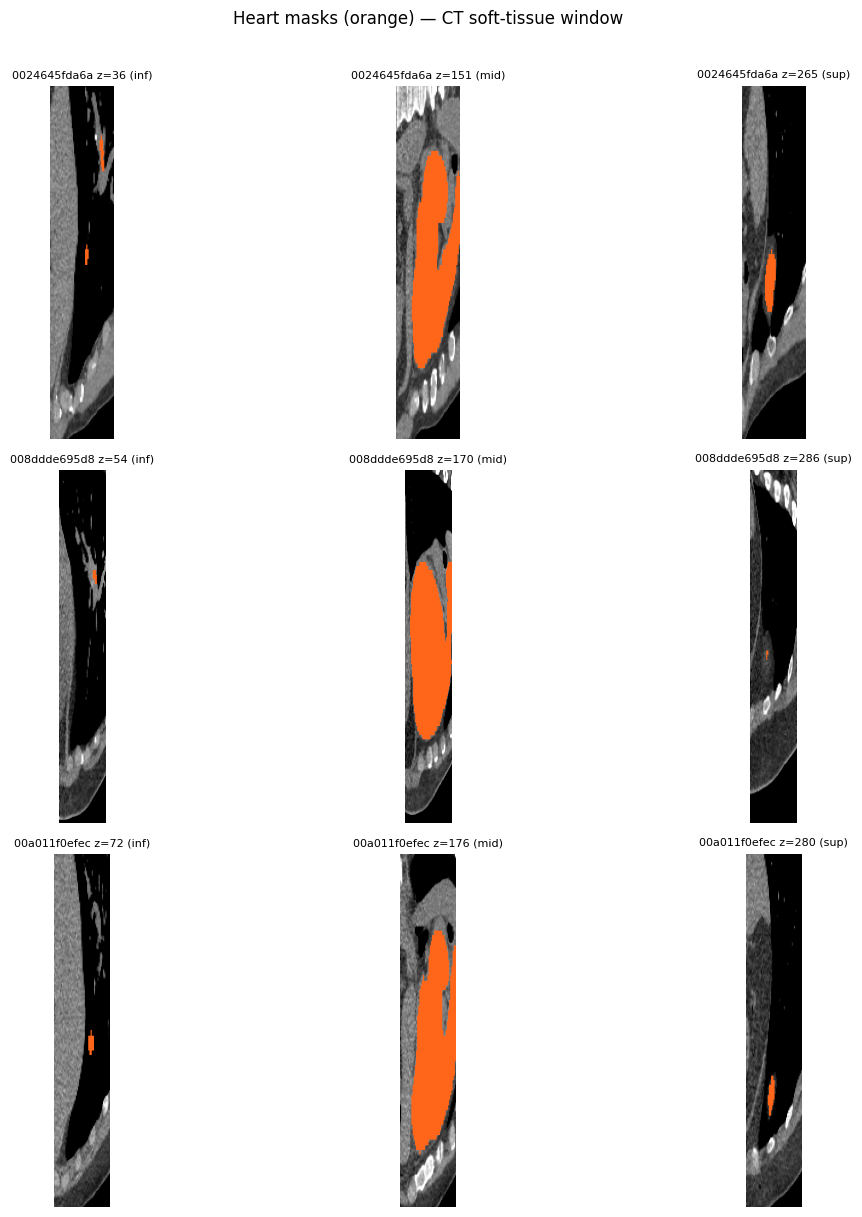

Saved fig01_heart_mask_overlays.png


In [ ]:

fig, axes = plt.subplots(len(test_patients), 3, figsize=(13, 4 * len(test_patients)))
if len(test_patients) == 1:
    axes = axes[np.newaxis, :]

for row_i, pid in enumerate(test_patients):
    ct_img = nib.load(RESAMPLED_DIR / pid / f"{pid}_img.nii.gz")
    ct = ct_img.get_fdata()
    heart = pilot_results[pid]["heart_img"].get_fdata()

    heart_slices = np.where(heart.sum(axis=(1, 2)) > 0)[0]
    if len(heart_slices) == 0:
        continue
    lo, mid, hi = heart_slices[0], heart_slices[len(heart_slices) // 2], heart_slices[-1]

    for col_i, z in enumerate([lo, mid, hi]):
        ax = axes[row_i, col_i]
        ct_slice = ct[z]
        heart_slice = heart[z]

        vmin, vmax = -200, 300
        ct_norm = np.clip((ct_slice - vmin) / (vmax - vmin), 0, 1)
        overlay = np.stack([ct_norm, ct_norm, ct_norm], axis=-1)
        overlay[heart_slice > 0] = [1.0, 0.4, 0.1]

        ax.imshow(overlay, origin="lower")
        label = {lo: "inf", mid: "mid", hi: "sup"}[z]
        ax.set_title(f"{pid} z={z} ({label})", fontsize=8)
        ax.axis("off")

plt.suptitle("Heart masks (orange) — CT soft-tissue window", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig01_heart_mask_overlays.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig01_heart_mask_overlays.png")

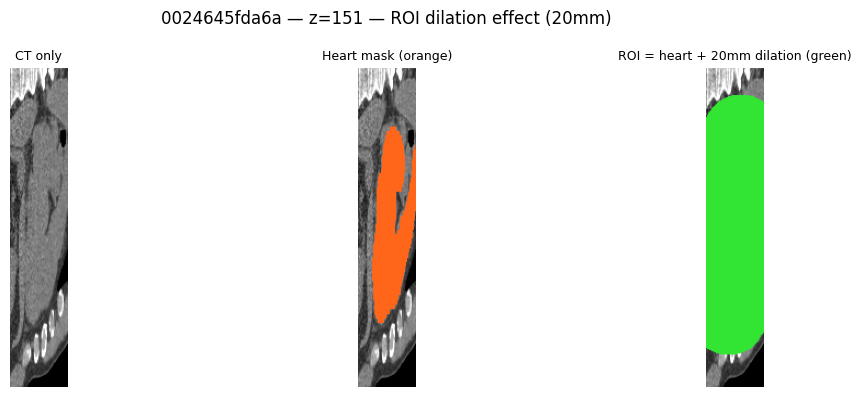

Saved fig02_roi_dilation.png


In [ ]:

dilation_mm = config["heart_roi"]["dilation_mm"]

def dilate_mask_mm(heart_img: nib.Nifti1Image, dilation_mm: float) -> nib.Nifti1Image:
    """Dilate the heart mask by dilation_mm using SimpleITK."""
    sitk_img = sitk.GetImageFromArray(heart_img.get_fdata().astype(np.uint8))
    zooms = [float(z) for z in heart_img.header.get_zooms()]
    sitk_img.SetSpacing(zooms)
    dil_radius_px = [int(np.ceil(dilation_mm / sp)) for sp in zooms]
    dilated = sitk.BinaryDilate(sitk_img, dil_radius_px)
    arr_dil = sitk.GetArrayFromImage(dilated)
    return nib.Nifti1Image(arr_dil, heart_img.affine, heart_img.header)

pid = test_patients[0]
roi_img = dilate_mask_mm(pilot_results[pid]["heart_img"], dilation_mm)
roi_arr = roi_img.get_fdata()
heart_arr = pilot_results[pid]["heart_img"].get_fdata()
ct = nib.load(RESAMPLED_DIR / pid / f"{pid}_img.nii.gz").get_fdata()

heart_slices = np.where(heart_arr.sum(axis=(1, 2)) > 0)[0]
z_mid = heart_slices[len(heart_slices) // 2]

vmin, vmax = -200, 300
ct_norm = np.clip((ct[z_mid] - vmin) / (vmax - vmin), 0, 1)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f"{pid} — z={z_mid} — ROI dilation effect ({dilation_mm}mm)")

for ax, (label, data, color) in zip(axes, [
    ("CT only", None, None),
    ("Heart mask (orange)", heart_arr[z_mid], [1.0, 0.4, 0.1]),
    (f"ROI = heart + {dilation_mm}mm dilation (green)", roi_arr[z_mid], [0.2, 0.9, 0.2]),
]):
    overlay = np.stack([ct_norm, ct_norm, ct_norm], axis=-1)
    if data is not None:
        overlay[data > 0] = color
    ax.imshow(overlay, origin="lower")
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig02_roi_dilation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig02_roi_dilation.png")

## Evaluation

In [10]:
roi_vol_ml = float(roi_img.get_fdata().sum() * np.prod(roi_img.header.get_zooms()) / 1000.0)
heart_vol_ml_pilot = float(stats_df["heart_vol_ml"].mean())

results = {
    "device": device,
    "fast_mode": config["totalsegmentator"]["fast"],
    "pilot_patients": len(test_patients),
    "avg_inference_time_s": float(avg_time),
    "estimated_total_time_h": float(avg_time * 787 / 3600),
    "heart_vol_ml_mean": heart_vol_ml_pilot,
    "heart_vol_ml_min": float(stats_df["heart_vol_ml"].min()),
    "heart_vol_ml_max": float(stats_df["heart_vol_ml"].max()),
    "roi_vol_ml_pilot0": roi_vol_ml,
    "dilation_mm": dilation_mm,
    "masks_saved_to": str(HEART_MASKS_DIR),
}

with open(METRICS_PATH, "w") as f:
    json.dump(results, f, indent=2)

print("=== Key metrics ===")
for k, v in results.items():
    print(f"  {k}: {v}")

=== Key metrics ===
  device: mps
  fast_mode: True
  pilot_patients: 3
  avg_inference_time_s: 0.0
  estimated_total_time_h: 0.0
  heart_vol_ml_mean: 1000.4579226351731
  heart_vol_ml_min: 916.4096982944757
  heart_vol_ml_max: 1161.677711779601
  roi_vol_ml_pilot0: 3790.0596064109805
  dilation_mm: 20
  masks_saved_to: /Users/shreyaschitransh/code/eat-segmentation/data/COCA_dataset/heart_masks
